# 04 - Timezone confirmation

To verify that timestamps corresponded to local clock time, we examined the population distribution of first and last light exposure. Lights-on times clustered around 07:00–09:00 and lights-off around 17:00–21:00, consistent with typical US daily schedules. This supports the assumption that timestamps represent local time rather than UTC.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyreadstat
import matplotlib.pyplot as plt


import ambient_light_epilepsy.nhanes as nhn
import ambient_light_epilepsy.cohort as ch
import time

In [4]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
from pathlib import Path


def compute_light_transition_hours(seqn_array, year, base_path, lux_threshold=50):
    """
    For each participant:
        - Bin lux into hourly means
        - Identify first hour where mean_lux > threshold  (lights-on)
        - Identify last hour where mean_lux > threshold   (lights-off)

    Returns DataFrame indexed by SEQN
    """

    results = []

    for seqn in seqn_array:

        file_path = Path(base_path) / f"PAXLUX_{year}" / "parquet_5min" / f"SEQN_{int(seqn)}_5min.parquet"

        if not file_path.exists():
            continue

        try:
            pf = pq.ParquetFile(file_path)
            table = pf.read(columns=["timestamp", "mean_lux"])
            df = table.to_pandas()

            if df.empty:
                continue

            # Ensure datetime
            df["timestamp"] = pd.to_datetime(df["timestamp"])

            # Extract hour of day (0–23)
            df["hour"] = df["timestamp"].dt.hour

            # Compute mean lux per hour across entire recording
            hourly_mean = df.groupby("hour")["mean_lux"].mean()

            # Identify hours above threshold
            bright_hours = hourly_mean[hourly_mean > lux_threshold]

            if bright_hours.empty:
                lights_on = np.nan
                lights_off = np.nan
            else:
                lights_on = bright_hours.index.min()
                lights_off = bright_hours.index.max()

            results.append({
                "SEQN": seqn,
                "lights_on_hour": lights_on,
                "lights_off_hour": lights_off
            })

        except Exception as e:
            print(f"Error processing {seqn}: {e}")

    return pd.DataFrame(results).set_index("SEQN")


In [7]:
base_path = "W:/projects/ambient_light_epilepsy_analysis/data"
year = "G"
control_seqn, pwe_seqn = ch.load_freq_matched_control_groups(year)

In [32]:
df_control_transitions = compute_light_transition_hours(
    control_seqn, year, base_path, lux_threshold=50
)

df_pwe_transitions = compute_light_transition_hours(
    pwe_seqn, year, base_path, lux_threshold=50
)


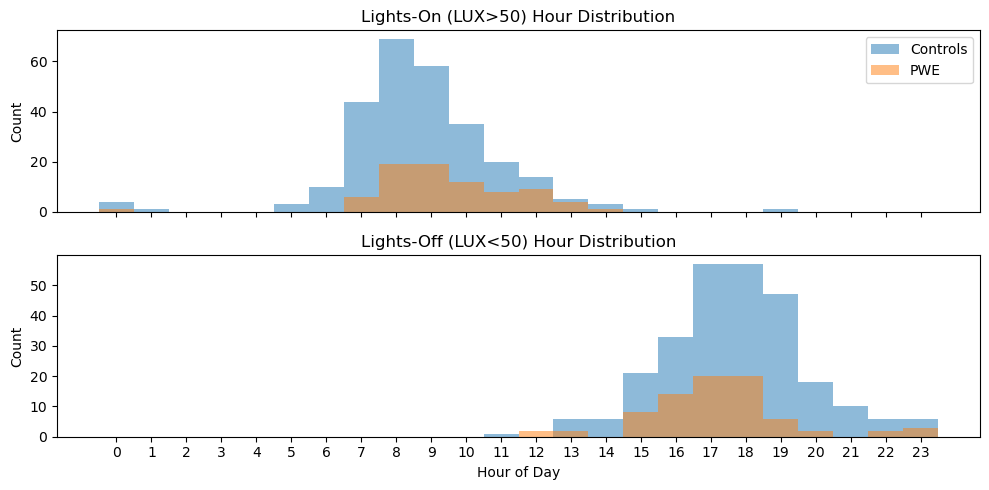

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def plot_light_transition_histograms(df_control, df_pwe, figsize=(10, 5)):

    bins = np.arange(-0.5, 24.5, 1)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    # ---- Top: Lights ON ----
    axes[0].hist(
        df_control["lights_on_hour"].dropna(),
        bins=bins,
        alpha=0.5,
        label="Controls"
    )

    axes[0].hist(
        df_pwe["lights_on_hour"].dropna(),
        bins=bins,
        alpha=0.5,
        label="PWE"
    )

    axes[0].set_ylabel("Count")
    axes[0].set_title("Lights-On (LUX>50) Hour Distribution")
    axes[0].legend()

    # ---- Bottom: Lights OFF ----
    axes[1].hist(
        df_control["lights_off_hour"].dropna(),
        bins=bins,
        alpha=0.5,
        label="Controls"
    )

    axes[1].hist(
        df_pwe["lights_off_hour"].dropna(),
        bins=bins,
        alpha=0.5,
        label="PWE"
    )

    axes[1].set_xlabel("Hour of Day")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Lights-Off (LUX<50) Hour Distribution")

    axes[1].set_xticks(range(24))

    plt.tight_layout()
    plt.show()


plot_light_transition_histograms(df_control_transitions, df_pwe_transitions)


In [29]:
file_path = Path(base_path) / f"PAXLUX_{year}" / "parquet_5min" / f"SEQN_{int(control_seqn[2])}_5min.parquet"



pf = pq.ParquetFile(file_path)
table = pf.read(columns=["timestamp", "mean_lux"])
df = table.to_pandas()

# Ensure datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract hour of day (0–23)
df["hour"] = df["timestamp"].dt.hour

# Compute mean lux per hour across entire recording
hourly_mean = df.groupby("hour")["mean_lux"].mean()

# Identify hours above threshold
bright_hours = hourly_mean[hourly_mean > 50]

if bright_hours.empty:
    lights_on = np.nan
    lights_off = np.nan
else:
    lights_on = bright_hours.index.min()
    lights_off = bright_hours.index.max()


# Create a daily LUX pattern by averaging over timepoints
daily_pattern = df.groupby(df['timestamp'].dt.time)['mean_lux'].mean()
daily_pattern.plot()

# Print lights on/off
print(f"Lights on: {lights_on}")
print(f"Lights off: {lights_off}")

In [30]:
hourly_mean

hour
0       0.008785
1       0.145486
2       0.039688
3       0.000000
4       0.000000
5       0.000000
6       0.000000
7       2.057222
8      79.399792
9      56.517674
10    110.900243
11     51.952951
12    172.628537
13    256.430417
14     65.636215
15    163.265312
16    421.415000
17    260.343056
18     92.214132
19     10.564271
20      4.068646
21      1.056563
22      1.429861
23      2.791806
Name: mean_lux, dtype: float64

In [31]:
lights_on

np.int32(8)

<Axes: xlabel='timestamp'>

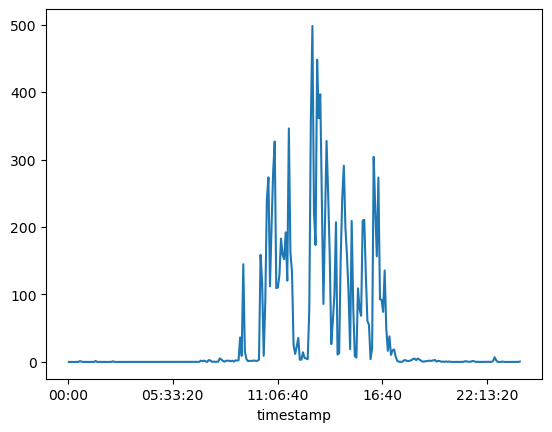

In [25]:
# Create a daily LUX pattern by averaging over timepoints
daily_pattern = df.groupby(df['timestamp'].dt.time)['mean_lux'].mean()
daily_pattern.plot()

In [8]:
# df_control_transitions = compute_light_transition_hours(
#     control_seqn, year, base_path, lux_threshold=50
# )

# df_pwe_transitions = compute_light_transition_hours(
#     pwe_seqn, year, base_path, lux_threshold=50
# )
